<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/4_4_DGE_Enrichment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4: Differential Gene Expression and Functional Enrichment Analysis

**Estimated time:** 120 minutes  **Prerequisites:** none — a synthetic RNA-Seq count matrix is generated inside the notebook.

### Learning Objectives
- Run a differential gene expression analysis on raw RNA-Seq counts (DESeq2-style, in Python).
- Explain how normalization and dispersion estimation work in a Negative-Binomial DGE model.
- Perform Over-Representation Analysis (ORA) and Gene Set Enrichment Analysis (GSEA) on a gene list.
- Interpret enrichment results in a biological context.

> This notebook uses `pydeseq2` (a Python reimplementation of DESeq2's statistical model) so the whole lab runs in one Colab kernel with no R installation required.

## Setup

In [1]:
%%capture
!pip -q install pydeseq2 gseapy

## Background

Differential Gene Expression (DGE) analysis identifies genes whose expression changes significantly between conditions (e.g., Control vs. Treated). **DESeq2** and **edgeR** both model raw, unnormalized RNA-Seq counts with Negative-Binomial generalized linear models, but differ in normalization (median-of-ratios in DESeq2 vs. Trimmed Mean of M-values in edgeR) and in how they shrink gene-wise dispersion estimates toward a shared trend. Once a gene list is produced, **functional annotation and enrichment analysis** translate it into biological meaning: **Gene Ontology (GO)** categorizes genes by Molecular Function, Cellular Component, and Biological Process, while pathway databases such as **KEGG** and **Reactome** map genes to known biochemical networks. **Over-Representation Analysis (ORA)** tests whether a category appears more often than expected by chance in a gene list (Fisher's Exact / hypergeometric test), while **Gene Set Enrichment Analysis (GSEA)** avoids an arbitrary significance cutoff by testing whether a gene set is enriched toward the top or bottom of an *entire* ranked gene list.

## Part A — Building a Synthetic RNA-Seq Dataset

We simulate 2,000 genes across 4 control and 4 treated samples. To make the later enrichment analysis meaningful, 30 of those genes carry **real human cell-cycle gene symbols** (CCNB1, CDK1, MCM2, …) and are deliberately upregulated in the treated group; another 30 carry **real interferon/immune-response gene symbols** and are left unchanged (a built-in negative control); the rest are anonymous filler genes.

In [2]:
import numpy as np
import pandas as pd

np.random.seed(0)

cell_cycle_genes = ["CCNB1","CCNB2","CCNE1","CDK1","CDK2","CDC20","PLK1","BUB1","BUB1B","MCM2",
                     "MCM3","MCM4","MCM5","MCM6","MCM7","PCNA","RRM2","TOP2A","AURKA","AURKB",
                     "CCNA2","CDC25A","CDC25C","E2F1","FOXM1","KIF11","KIF23","TTK","ESPL1","CENPA"]
immune_genes = ["IFI6","ISG15","MX1","MX2","OAS1","OAS2","OAS3","STAT1","STAT2","IRF7",
                 "IRF9","IFIT1","IFIT3","IFI44","IFI44L","RSAD2","USP18","XAF1","CXCL10","IFITM1",
                 "IFITM3","OASL","HERC5","DDX58","IFIH1","BST2","SAMD9","EPSTI1","LY6E","PARP9"]

N_TOTAL_GENES = 2000
n_filler = N_TOTAL_GENES - len(cell_cycle_genes) - len(immune_genes)
filler_genes = [f"Gene{i:04d}" for i in range(n_filler)]
all_genes = cell_cycle_genes + immune_genes + filler_genes

N_PER_GROUP = 4
dispersion = 0.15
base_mean = np.random.uniform(20, 500, size=len(all_genes))
cc_index = set(range(len(cell_cycle_genes)))  # cell-cycle genes get a true fold change

def nb_counts(mean, disp, n):
    r = 1 / disp
    p = r / (r + mean)
    return np.random.negative_binomial(r, p, size=n)

counts = np.zeros((len(all_genes), N_PER_GROUP * 2), dtype=int)
for i in range(len(all_genes)):
    fc = np.random.uniform(2.0, 4.0) if i in cc_index else 1.0
    counts[i, :N_PER_GROUP] = nb_counts(base_mean[i], dispersion, N_PER_GROUP)
    counts[i, N_PER_GROUP:] = nb_counts(base_mean[i] * fc, dispersion, N_PER_GROUP)

sample_names = [f"control_{i+1}" for i in range(N_PER_GROUP)] + [f"treated_{i+1}" for i in range(N_PER_GROUP)]
counts_df = pd.DataFrame(counts, index=all_genes, columns=sample_names)
metadata = pd.DataFrame({"condition": ["control"] * N_PER_GROUP + ["treated"] * N_PER_GROUP}, index=sample_names)

counts_df.head()


,control_1,control_2,control_3,control_4,treated_1,treated_2,treated_3,treated_4
CCNB1,603,77,115,109,817,1840,579,654
CCNB2,369,597,201,484,799,1329,817,1112
CCNE1,420,124,534,340,587,681,1183,328
CDK1,310,492,257,229,719,596,511,433
CDK2,258,170,144,142,833,640,711,548


## Part A (continued) — Running DESeq2 (`pydeseq2`)

In [3]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

dds = DeseqDataSet(counts=counts_df.T, metadata=metadata, design="~condition", refit_cooks=True)
dds.deseq2()

stat_res = DeseqStats(dds, contrast=["condition", "treated", "control"])
stat_res.summary()
results = stat_res.results_df
results.to_csv("deseq_results.csv")
results.sort_values("padj").head(10)


Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 2.36 seconds.

Fitting dispersion trend curve...
... done in 0.10 seconds.

Fitting MAP dispersions...
... done in 3.12 seconds.

Fitting LFCs...
... done in 2.57 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: condition treated vs control
            baseMean  log2FoldChange     lfcSE      stat        pvalue  \
CCNB1     583.401956        2.098085  0.777135  2.699769  6.938768e-03   
CCNB2     695.282785        1.292664  0.381990  3.384026  7.143116e-04   
CCNE1     510.231770        0.967300  0.461375  2.096559  3.603266e-02   
CDK1      431.576235        0.806050  0.350566  2.299282  2.148893e-02   
CDK2      419.167124        1.930787  0.332586  5.805378  6.422113e-09   
...              ...             ...       ...       ...           ...   
Gene1935  345.154610       -0.532469  0.332066 -1.603505  1.088233e-01   
Gene1936  308.886497       -0.721163  0.430576 -1.674878  9.395809e-02   
Gene1937  262.173550        0.008224  0.352712  0.023318  9.813969e-01   
Gene1938  274.228255       -0.259925  0.454081 -0.572421  5.670365e-01   
Gene1939  259.323918        0.079606  0.340388  0.233869  8.150871e-01   

              padj  
CCNB1     0.225683  
CC

... done in 0.79 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
CENPA,691.592196,2.410617,0.329359,7.319109,2.496232e-13,1.623799e-10
MCM4,640.029543,2.280151,0.308534,7.390275,1.465251e-13,1.623799e-10
CDC20,716.954823,1.861197,0.307126,6.060035,1.360919e-09,5.901854e-07
CDK2,419.167124,1.930787,0.332586,5.805378,6.422113e-09,1.769630e-06
CCNA2,1155.167367,2.105919,0.363355,5.795765,6.801036e-09,1.769630e-06
MCM3,827.438118,2.034495,0.358828,5.669840,1.429306e-08,3.099211e-06
KIF11,590.222846,1.553815,0.303168,5.125254,2.971368e-07,5.522500e-05
AURKB,878.163149,1.831369,0.371381,4.931246,8.170656e-07,1.328753e-04
Gene1733,380.388726,1.143106,0.304919,3.748878,1.776273e-04,1.850952e-02
BUB1,1013.776470,1.661202,0.438273,3.790334,1.504448e-04,1.850952e-02


In [4]:
SIG_PADJ = 0.05
SIG_LFC = 1.0
sig = results[(results["padj"] < SIG_PADJ) & (results["log2FoldChange"].abs() > SIG_LFC)]
sig_genes = list(sig.index)
print(f"{len(sig_genes)} significant genes at padj < {SIG_PADJ} and |log2FC| > {SIG_LFC}")
sig.sort_values("log2FoldChange", ascending=False)


19 significant genes at padj < 0.05 and |log2FC| > 1.0


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
CENPA,691.592196,2.410617,0.329359,7.319109,2.496232e-13,1.623799e-10
MCM4,640.029543,2.280151,0.308534,7.390275,1.465251e-13,1.623799e-10
CCNA2,1155.167367,2.105919,0.363355,5.795765,6.801036e-09,1.769630e-06
MCM3,827.438118,2.034495,0.358828,5.669840,1.429306e-08,3.099211e-06
CDK2,419.167124,1.930787,0.332586,5.805378,6.422113e-09,1.769630e-06
ESPL1,564.519255,1.866064,0.493703,3.779730,1.569984e-04,1.850952e-02
CDC20,716.954823,1.861197,0.307126,6.060035,1.360919e-09,5.901854e-07
AURKB,878.163149,1.831369,0.371381,4.931246,8.170656e-07,1.328753e-04
BUB1,1013.776470,1.661202,0.438273,3.790334,1.504448e-04,1.850952e-02
KIF11,590.222846,1.553815,0.303168,5.125254,2.971368e-07,5.522500e-05


**Q1.** How many genes are significant? What fraction of the 30 planted cell-cycle genes made the cutoff — and does that surprise you, given that we simulated real biological + sampling noise with only 4 replicates per group?

_Your answer:_



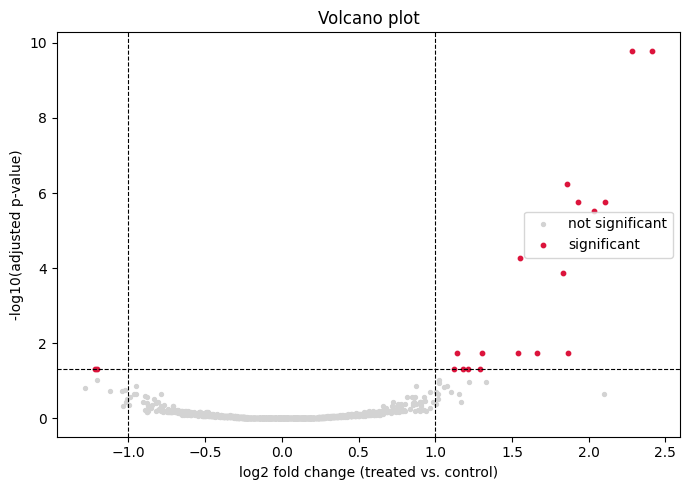

In [5]:
import matplotlib.pyplot as plt

plot_df = results.dropna(subset=["padj", "log2FoldChange"]).copy()
plot_df["neg_log10_padj"] = -np.log10(plot_df["padj"].clip(lower=1e-300))
is_sig = (plot_df["padj"] < SIG_PADJ) & (plot_df["log2FoldChange"].abs() > SIG_LFC)

plt.figure(figsize=(7, 5))
plt.scatter(plot_df.loc[~is_sig, "log2FoldChange"], plot_df.loc[~is_sig, "neg_log10_padj"],
            s=8, color="lightgray", label="not significant")
plt.scatter(plot_df.loc[is_sig, "log2FoldChange"], plot_df.loc[is_sig, "neg_log10_padj"],
            s=10, color="crimson", label="significant")
plt.axvline(SIG_LFC, color="black", linestyle="--", linewidth=0.8)
plt.axvline(-SIG_LFC, color="black", linestyle="--", linewidth=0.8)
plt.axhline(-np.log10(SIG_PADJ), color="black", linestyle="--", linewidth=0.8)
plt.xlabel("log2 fold change (treated vs. control)")
plt.ylabel("-log10(adjusted p-value)")
plt.title("Volcano plot")
plt.legend()
plt.tight_layout()
plt.show()


**Q2.** Identify the three most significantly upregulated and three most significantly downregulated genes from the volcano plot / results table. Are any of the downregulated genes expected, given how we built the dataset?

_Your answer:_



## Part B — Cross-Checking with edgeR (Optional / Advanced)

`pydeseq2` reimplements DESeq2's statistical model directly in Python. edgeR is an R package; to run it from this notebook you would need R plus the `rpy2` bridge (or `%%R` cell magic via `rpy2.ipython`), which is heavier to set up. If you want to attempt the cross-check, the outline below (not run by default) is the standard approach:

```python
# Optional — requires R and BiocManager::install("edgeR") in the R environment first.
# %load_ext rpy2.ipython
# %%R -i counts_df -i metadata
# library(edgeR)
# y <- DGEList(counts = t(counts_df), group = metadata$condition)
# y <- calcNormFactors(y)                 # TMM normalization
# design <- model.matrix(~condition, data = metadata)
# y <- estimateDisp(y, design)
# fit <- glmQLFit(y, design)
# qlf <- glmQLFTest(fit, coef = 2)
# topTags(qlf, n = 10)
```

**Q3.** If you do run edgeR, compare the number of significant genes and the top hits to the DESeq2 results above. If you don't, based on the background material, what is the main methodological difference that could cause the two tools to disagree slightly on borderline genes?

_Your answer:_



## Part C — Functional Enrichment

We use `gseapy` with two small, self-contained gene sets — our known **Cell_Cycle_Genes** and **Immune_Response_Genes** lists — so the enrichment runs entirely offline. (In a real project you would instead query public libraries such as `GO_Biological_Process_2021` or `KEGG_2021_Human` via `gseapy.enrichr(...)`, which requires an internet connection to the Enrichr web service; see the note at the end of this section.)

In [6]:
import gseapy as gp

gene_sets = {"Cell_Cycle_Genes": cell_cycle_genes, "Immune_Response_Genes": immune_genes}

ora = gp.enrich(gene_list=sig_genes, gene_sets=gene_sets, background=all_genes, outdir=None)
ora.results[["Term", "Overlap", "P-value", "Adjusted P-value", "Genes"]]


,Term,Overlap,P-value,Adjusted P-value,Genes
0,Cell_Cycle_Genes,14/30,9.068313e-24,9.068313e-24,MCM6;CDK2;CCNA2;CENPA;CDC20;KIF11;MCM3;CCNB2;M...


**Q4.** Which gene set(s) show up as significantly over-represented? Does the immune-response gene set appear at all — and does that match how the dataset was built?

_Your answer:_



In [7]:
results_ranked = results.dropna(subset=["stat"]).reset_index().rename(columns={"index": "gene"})
rnk = results_ranked[["gene", "stat"]].sort_values("stat", ascending=False)

gsea_res = gp.prerank(rnk=rnk, gene_sets=gene_sets, min_size=5, max_size=500,
                       permutation_num=200, seed=0, outdir=None)
gsea_res.res2d[["Term", "ES", "NES", "NOM p-val", "FDR q-val"]]


,Term,ES,NES,NOM p-val,FDR q-val
0,Cell_Cycle_Genes,0.940991,3.096282,0.000000,0.00
1,Immune_Response_Genes,-0.183522,-0.647743,0.964706,0.95


**Q5.** Compare the GSEA normalized enrichment score (NES) for each gene set to the ORA result above. Do the two methods agree on which pathway is enriched?

_Your answer:_



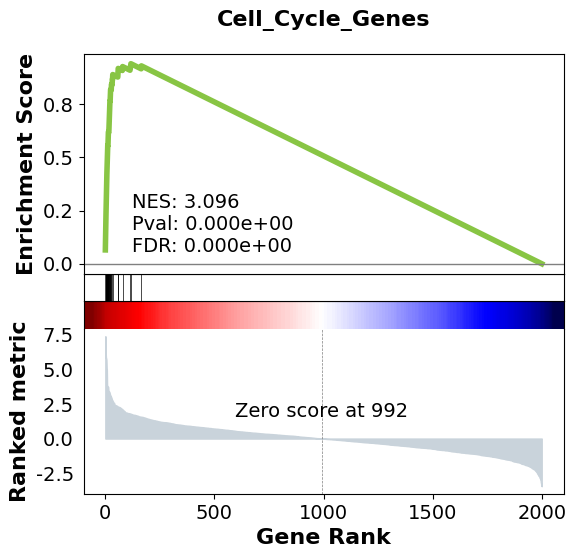

In [8]:
from gseapy.plot import gseaplot

term = "Cell_Cycle_Genes"
gseaplot(rank_metric=gsea_res.ranking, term=term, **gsea_res.results[term])
plt.show()


**Q6.** Looking at the running-enrichment-score plot, where along the ranked gene list does the enrichment score peak? Explain, using this plot, one scenario in which GSEA might detect a biologically relevant pathway that ORA — which only looks at genes past a hard significance cutoff — would miss.

_Your answer:_



**Optional — querying real GO/KEGG libraries.** If your Colab runtime has internet access, you can query the live Enrichr service against real annotation databases instead of our two toy gene sets:

In [9]:
# Optional, requires internet access to https://maayanlab.cloud (Enrichr):
# enr_real = gp.enrichr(gene_list=sig_genes, gene_sets=["GO_Biological_Process_2021", "KEGG_2021_Human"],
#                        organism="human", outdir=None)
# enr_real.results.sort_values("Adjusted P-value").head(5)


## Discussion Questions

**Q7.** Why do DESeq2 and edgeR require raw, unnormalized counts rather than already-normalized values such as FPKM/TPM as input?

_Your answer:_



**Q8.** What is the practical consequence of choosing an overly lenient vs. overly strict adjusted p-value cutoff when defining the significant gene list? Try changing `SIG_PADJ` and `SIG_LFC` above and re-running Part A — how does `sig_genes` change?

_Your answer:_



**Q9.** If your enrichment analysis returned a highly significant but biologically implausible pathway, what would you check before trusting the result?

_Your answer:_



---
### Deliverable
The DESeq2 results table (`deseq_results.csv`), the volcano plot, the ORA and GSEA result tables, the GSEA running-enrichment plot, and your written answers to Parts A–C and the discussion questions.